# Google Colab Setup

This section prepares the Colab environment before running the VGG16 project.

It creates the project folders, downloads the dataset, adds the shared `src` files, checks the dataset, and confirms that the GPU is available.


In [1]:
from pathlib import Path
import os

COLAB_PROJECT = Path("/content/brain-tumour-mri-classification")

DATA_DIR = COLAB_PROJECT / "data"
SRC_DIR = COLAB_PROJECT / "src"
RESULTS_DIR = COLAB_PROJECT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"
CHECKPOINTS_DIR = RESULTS_DIR / "checkpoints"

for folder in [
    DATA_DIR,
    SRC_DIR,
    FIGURES_DIR,
    METRICS_DIR,
    CHECKPOINTS_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

# Make the Colab project folder the working directory.
os.chdir(COLAB_PROJECT)

print("Project:", COLAB_PROJECT)
print("Data:", DATA_DIR)
print("Results:", RESULTS_DIR)


Project: /content/brain-tumour-mri-classification
Data: /content/brain-tumour-mri-classification/data
Results: /content/brain-tumour-mri-classification/results


### Download the Dataset

Download the same Brain Tumor MRI dataset used by the project directly from Kaggle.


In [2]:
!pip -q install kaggle

!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset \
    -p /content/brain-tumour-mri-classification/data


Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:02<00:00, 73.1MB/s]



### Extract and Check the Dataset

Extract the downloaded dataset and confirm the four classes and image counts.


In [3]:
import zipfile

zip_path = DATA_DIR / "brain-tumor-mri-dataset.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(DATA_DIR)

print("Dataset extracted successfully.")


Dataset extracted successfully.


In [4]:
CLASS_NAMES_SETUP = ["glioma", "meningioma", "notumor", "pituitary"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

overall_total = 0

for split in ["Training", "Testing"]:
    print(f"\n{split}")
    split_total = 0

    for class_name in CLASS_NAMES_SETUP:
        class_path = DATA_DIR / split / class_name

        images = [
            file
            for file in class_path.iterdir()
            if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
        ]

        count = len(images)
        split_total += count
        print(f"{class_name:12s}: {count}")

    print(f"{split} total: {split_total}")
    overall_total += split_total

print(f"\nOverall total: {overall_total}")

assert overall_total == 7200, "Unexpected dataset size."



Training
glioma      : 1400
meningioma  : 1400
notumor     : 1400
pituitary   : 1400
Training total: 5600

Testing
glioma      : 400
meningioma  : 400
notumor     : 400
pituitary   : 400
Testing total: 1600

Overall total: 7200


### Add the Shared Source Files

Upload `dataset.py`, `transforms.py`, and `utils.py` from the project's local `src` folder.

These files are shared by the model notebooks.


In [6]:
from pathlib import Path
import shutil

required_src_files = ["dataset.py", "transforms.py", "utils.py"]

for filename in required_src_files:
    source = COLAB_PROJECT / filename
    destination = SRC_DIR / filename

    if source.exists():
        shutil.move(str(source), str(destination))
        print(f"Added: {filename}")
    elif destination.exists():
        print(f"Already in src: {filename}")
    else:
        print(f"Missing: {filename}")

Added: dataset.py
Added: transforms.py
Added: utils.py


In [7]:
print("src files:")

for file in sorted(SRC_DIR.iterdir()):
    print(" -", file.name)

print("\nTraining exists:", (DATA_DIR / "Training").exists())
print("Testing exists:", (DATA_DIR / "Testing").exists())


src files:
 - dataset.py
 - transforms.py
 - utils.py

Training exists: True
Testing exists: True


### Check the Colab GPU

Confirm that Colab is using a CUDA GPU before starting VGG16 training.


In [8]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "GPU is not enabled. Select a GPU from Runtime > Change runtime type."
    )


PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA available: True
GPU: Tesla T4


**Colab setup is complete.** Continue with the project notebook below and run the remaining cells from top to bottom.


# VGG16 Transfer Learning — Brain Tumour MRI Classification

This notebook develops the VGG16 model for our brain tumour MRI classification project.

The model classifies MRI images into four classes: **glioma, meningioma, no tumour, and pituitary**.

Training is done in two stages:
1. Train the classifier while the VGG16 feature layers are frozen.
2. Unfreeze the last VGG16 block and fine-tune the model.

The test set is used only for the final evaluation.


## 1. Environment Setup

Import the libraries, set the random seed, and select CPU or GPU for the model.


In [9]:
import sys
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision

from torch.optim import Adam
from torchvision.models import vgg16, VGG16_Weights
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.13.15
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
Device: cuda
GPU: Tesla T4


## 2. Project Configuration

Set the project paths and the main settings used for VGG16 training. Result folders are also created here.


In [10]:
cwd = Path.cwd().resolve()

if (cwd / "src").exists() and (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists() and (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Project root not found. Run this notebook from the project root "
        "or from the notebooks folder."
    )

DATA_ROOT = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"
CHECKPOINTS_DIR = RESULTS_DIR / "checkpoints"

for folder in [RESULTS_DIR, FIGURES_DIR, METRICS_DIR, CHECKPOINTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BATCH_SIZE = 32
NUM_CLASSES = 4
IMAGE_SIZE = 224
CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]

PHASE1_EPOCHS = 10
FINETUNE_EPOCHS = 25
PHASE1_LR = 1e-3
FINETUNE_LR = 1e-4

PHASE1_CHECKPOINT = CHECKPOINTS_DIR / "vgg16_phase1_best.pth"
FINETUNE_CHECKPOINT = CHECKPOINTS_DIR / "vgg16_finetuned_best.pth"
FINAL_MODEL_PATH = CHECKPOINTS_DIR / "vgg16_final.pth"

print("Project root:", PROJECT_ROOT)
print("Data root:", DATA_ROOT)
print("Figures:", FIGURES_DIR)
print("Metrics:", METRICS_DIR)
print("Checkpoints:", CHECKPOINTS_DIR)


Project root: /content/brain-tumour-mri-classification
Data root: /content/brain-tumour-mri-classification/data
Figures: /content/brain-tumour-mri-classification/results/figures
Metrics: /content/brain-tumour-mri-classification/results/metrics
Checkpoints: /content/brain-tumour-mri-classification/results/checkpoints


## 3. Load the Dataset

Load the training, validation, and testing data using the shared dataset code in the project.


In [11]:
from src.dataset import get_dataloaders

train_loader, val_loader, test_loader = get_dataloaders(
    str(DATA_ROOT),
    batch_size=BATCH_SIZE
)

print("Class mapping:", train_loader.dataset.dataset.class_to_idx)


Train:      4,480 images
Validation: 1,120 images
Test:       1,600 images
Classes:    ['glioma', 'meningioma', 'notumor', 'pituitary']
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


## 4. Check the Input Data

Check one batch to make sure the images and labels have the correct shapes. VGG16 uses `224 × 224` RGB images.


In [12]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("First labels:", labels[:10])

assert images.ndim == 4
assert images.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE)
assert labels.ndim == 1


Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
First labels: tensor([0, 0, 0, 0, 2, 3, 0, 2, 0, 1])


## 5. View Sample MRI Images

Display a few training images with their class names to check the dataset visually.


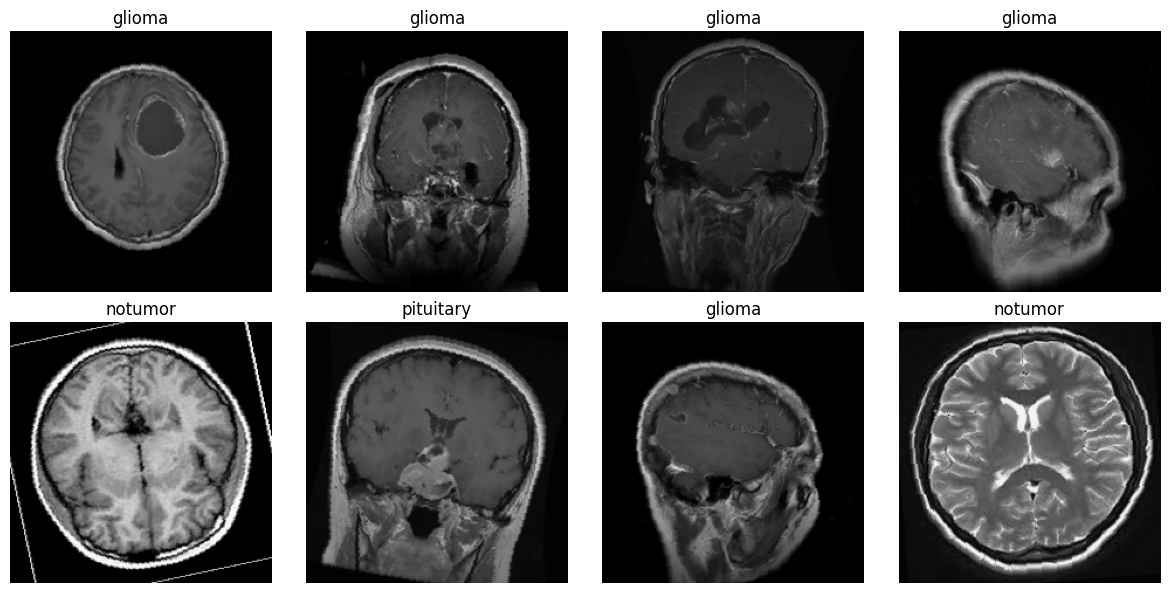

In [13]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, image, label in zip(axes.flat, images[:8], labels[:8]):
    display_image = image.cpu() * IMAGENET_STD + IMAGENET_MEAN
    display_image = display_image.clamp(0, 1).permute(1, 2, 0).numpy()

    ax.imshow(display_image)
    ax.set_title(CLASS_NAMES[label.item()])
    ax.axis("off")

plt.tight_layout()
plt.show()


## 6. Create the VGG16 Model

Load the ImageNet pretrained VGG16 model and change the final layer for our 4 classes.

First, freeze the feature layers and train only the classifier.


In [14]:
def create_vgg16_model(num_classes=NUM_CLASSES):
    model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1)

    # Freeze the convolutional feature extractor for Phase 1.
    for parameter in model.features.parameters():
        parameter.requires_grad = False

    # Replace the original ImageNet output layer.
    in_features = model.classifier[6].in_features
    model.classifier[6] = nn.Linear(in_features, num_classes)

    return model


model = create_vgg16_model().to(device)

print("Fresh VGG16 model created.")
print("Final layer:", model.classifier[6])


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:08<00:00, 67.6MB/s]


Fresh VGG16 model created.
Final layer: Linear(in_features=4096, out_features=4, bias=True)


## 7. Check the Model

Check the total and trainable parameters and make sure the model gives 4 outputs for each image.


In [15]:
def count_parameters(model):
    total = sum(parameter.numel() for parameter in model.parameters())
    trainable = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )
    return total, trainable


total_params, trainable_params = count_parameters(model)

model.eval()
with torch.no_grad():
    sample_output = model(images[:2].to(device))

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("Input shape:", images[:2].shape)
print("Output shape:", sample_output.shape)

assert sample_output.shape == (2, NUM_CLASSES)


Total parameters:     134,276,932
Trainable parameters: 119,562,244
Input shape: torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 4])


## 8. Training and Validation Functions

Create functions for one training epoch and one validation epoch. They calculate the loss and accuracy.


In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_images, batch_labels in loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(batch_images)
        loss = criterion(outputs, batch_labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * batch_images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == batch_labels).sum().item()
        total += batch_labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_images, batch_labels in loader:
            batch_images = batch_images.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_images)
            loss = criterion(outputs, batch_labels)

            running_loss += loss.item() * batch_images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == batch_labels).sum().item()
            total += batch_labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


## 9. Training Function

This function runs the training for several epochs, keeps the training history, and saves the model with the best validation accuracy.


In [17]:
def run_training_stage(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs,
    checkpoint_path,
    stage_name
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_acc = -1.0
    best_epoch = 0
    stage_start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        epoch_start = time.perf_counter()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc = validate_one_epoch(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_accuracy": val_acc,
                    "class_names": CLASS_NAMES
                },
                checkpoint_path
            )

        elapsed = time.perf_counter() - epoch_start

        print(
            f"{stage_name} | Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Time: {elapsed:.1f}s"
        )

    total_time = time.perf_counter() - stage_start

    print(f"\nBest validation accuracy: {best_val_acc:.4f}")
    print(f"Best epoch: {best_epoch}")
    print(f"Training time: {total_time / 60:.2f} minutes")
    print(f"Saved checkpoint: {checkpoint_path}")

    return history, best_val_acc, best_epoch, total_time


## 10. Phase 1 — Frozen Training

For the first stage, keep the VGG16 feature layers frozen and train the classifier using cross-entropy loss and Adam.


In [18]:
criterion = nn.CrossEntropyLoss()

phase1_optimizer = Adam(
    filter(lambda parameter: parameter.requires_grad, model.parameters()),
    lr=PHASE1_LR
)

print("Phase 1 learning rate:", PHASE1_LR)
print("Phase 1 epochs:", PHASE1_EPOCHS)
print(
    "Trainable tensors:",
    sum(1 for parameter in model.parameters() if parameter.requires_grad)
)


Phase 1 learning rate: 0.001
Phase 1 epochs: 10
Trainable tensors: 6


## 11. Run Phase 1 Training

Train the frozen VGG16 model and save the checkpoint with the best validation accuracy.


In [19]:
phase1_history, phase1_best_val_acc, phase1_best_epoch, phase1_time = run_training_stage(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=phase1_optimizer,
    epochs=PHASE1_EPOCHS,
    checkpoint_path=PHASE1_CHECKPOINT,
    stage_name="Phase 1"
)


Phase 1 | Epoch 01/10 | Train Loss: 0.7745 | Train Acc: 0.7491 | Val Loss: 0.8935 | Val Acc: 0.7732 | Time: 44.7s
Phase 1 | Epoch 02/10 | Train Loss: 0.6068 | Train Acc: 0.8373 | Val Loss: 0.3308 | Val Acc: 0.8866 | Time: 44.0s
Phase 1 | Epoch 03/10 | Train Loss: 0.5444 | Train Acc: 0.8473 | Val Loss: 0.3120 | Val Acc: 0.8929 | Time: 49.7s
Phase 1 | Epoch 04/10 | Train Loss: 0.4732 | Train Acc: 0.8672 | Val Loss: 0.4274 | Val Acc: 0.8848 | Time: 37.4s
Phase 1 | Epoch 05/10 | Train Loss: 0.4847 | Train Acc: 0.8752 | Val Loss: 0.2599 | Val Acc: 0.9071 | Time: 61.1s
Phase 1 | Epoch 06/10 | Train Loss: 0.4630 | Train Acc: 0.8792 | Val Loss: 0.3618 | Val Acc: 0.8920 | Time: 38.4s
Phase 1 | Epoch 07/10 | Train Loss: 0.4286 | Train Acc: 0.8842 | Val Loss: 0.3163 | Val Acc: 0.8946 | Time: 38.0s
Phase 1 | Epoch 08/10 | Train Loss: 0.3635 | Train Acc: 0.9004 | Val Loss: 0.3165 | Val Acc: 0.8786 | Time: 37.7s
Phase 1 | Epoch 09/10 | Train Loss: 0.3661 | Train Acc: 0.9031 | Val Loss: 0.1923 | Val 

## 12. Phase 1 Learning Curves

Plot training and validation loss and accuracy to see how the model learned during Phase 1.


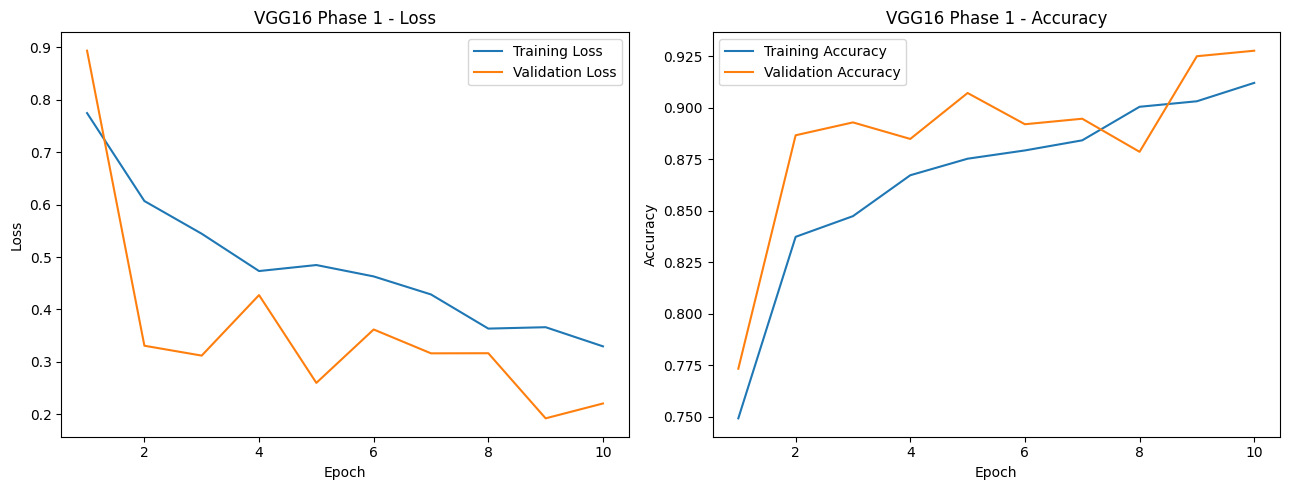

In [20]:
def plot_history(history, title, save_path):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(epochs, history["train_loss"], label="Training Loss")
    axes[0].plot(epochs, history["val_loss"], label="Validation Loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Training Accuracy")
    axes[1].plot(epochs, history["val_acc"], label="Validation Accuracy")
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_history(
    phase1_history,
    "VGG16 Phase 1",
    FIGURES_DIR / "vgg16_phase1_learning_curves.png"
)


## 13. Load the Best Phase 1 Model

Load the best Phase 1 checkpoint before starting fine-tuning.


In [21]:
phase1_checkpoint = torch.load(
    PHASE1_CHECKPOINT,
    map_location=device,
    weights_only=False
)

model.load_state_dict(phase1_checkpoint["model_state_dict"])

print("Loaded Phase 1 checkpoint.")
print("Best Phase 1 epoch:", phase1_checkpoint["epoch"])
print(
    "Best Phase 1 validation accuracy:",
    f"{phase1_checkpoint['val_accuracy']:.4f}"
)


Loaded Phase 1 checkpoint.
Best Phase 1 epoch: 10
Best Phase 1 validation accuracy: 0.9277


## 14. Phase 2 — Fine-Tuning Setup

Unfreeze the last VGG16 block and keep the earlier feature layers frozen.

Use a smaller learning rate for fine-tuning.


In [22]:
# Freeze all convolutional features first.
for parameter in model.features.parameters():
    parameter.requires_grad = False

# Unfreeze the final VGG16 convolutional block.
for parameter in model.features[24:].parameters():
    parameter.requires_grad = True

# Keep the classifier trainable.
for parameter in model.classifier.parameters():
    parameter.requires_grad = True

total_params, finetune_trainable_params = count_parameters(model)

finetune_optimizer = Adam(
    filter(lambda parameter: parameter.requires_grad, model.parameters()),
    lr=FINETUNE_LR
)

print(f"Total parameters:                {total_params:,}")
print(f"Fine-tuning trainable parameters: {finetune_trainable_params:,}")
print("Fine-tuning learning rate:", FINETUNE_LR)
print("Fine-tuning epochs:", FINETUNE_EPOCHS)


Total parameters:                134,276,932
Fine-tuning trainable parameters: 126,641,668
Fine-tuning learning rate: 0.0001
Fine-tuning epochs: 25


## 15. Run Fine-Tuning

Continue training the model after unfreezing the last VGG16 block. Save the checkpoint with the best validation accuracy.


In [23]:
finetune_history, finetune_best_val_acc, finetune_best_epoch, finetune_time = run_training_stage(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=finetune_optimizer,
    epochs=FINETUNE_EPOCHS,
    checkpoint_path=FINETUNE_CHECKPOINT,
    stage_name="Fine-Tuning"
)


Fine-Tuning | Epoch 01/25 | Train Loss: 0.2758 | Train Acc: 0.9174 | Val Loss: 0.2415 | Val Acc: 0.9295 | Time: 145.0s
Fine-Tuning | Epoch 02/25 | Train Loss: 0.1898 | Train Acc: 0.9359 | Val Loss: 0.2041 | Val Acc: 0.9420 | Time: 119.5s
Fine-Tuning | Epoch 03/25 | Train Loss: 0.1669 | Train Acc: 0.9464 | Val Loss: 0.2070 | Val Acc: 0.9420 | Time: 40.6s
Fine-Tuning | Epoch 04/25 | Train Loss: 0.1099 | Train Acc: 0.9652 | Val Loss: 0.1904 | Val Acc: 0.9500 | Time: 145.1s
Fine-Tuning | Epoch 05/25 | Train Loss: 0.1257 | Train Acc: 0.9589 | Val Loss: 0.1535 | Val Acc: 0.9670 | Time: 119.8s
Fine-Tuning | Epoch 06/25 | Train Loss: 0.0761 | Train Acc: 0.9790 | Val Loss: 0.2025 | Val Acc: 0.9589 | Time: 40.6s
Fine-Tuning | Epoch 07/25 | Train Loss: 0.0912 | Train Acc: 0.9759 | Val Loss: 0.1418 | Val Acc: 0.9652 | Time: 40.3s
Fine-Tuning | Epoch 08/25 | Train Loss: 0.0936 | Train Acc: 0.9728 | Val Loss: 0.1763 | Val Acc: 0.9491 | Time: 40.5s
Fine-Tuning | Epoch 09/25 | Train Loss: 0.0694 | Tra

## 16. Fine-Tuning Learning Curves

Plot the loss and accuracy curves for the fine-tuning stage.


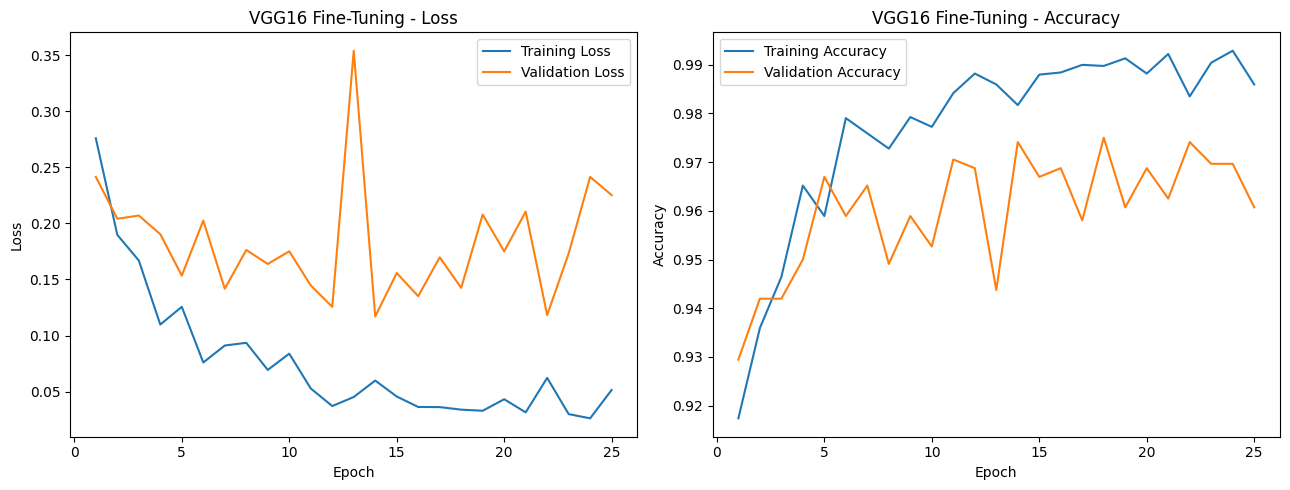

In [24]:
plot_history(
    finetune_history,
    "VGG16 Fine-Tuning",
    FIGURES_DIR / "vgg16_finetuned_learning_curves.png"
)


## 17. Load the Best Fine-Tuned Model

Load the fine-tuned checkpoint with the best validation accuracy before evaluation.


In [25]:
best_checkpoint = torch.load(
    FINETUNE_CHECKPOINT,
    map_location=device,
    weights_only=False
)

model.load_state_dict(best_checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Best fine-tuned model loaded.")
print("Best epoch:", best_checkpoint["epoch"])
print(
    "Best validation accuracy:",
    f"{best_checkpoint['val_accuracy']:.4f}"
)


Best fine-tuned model loaded.
Best epoch: 18
Best validation accuracy: 0.9750


## 18. Prediction Function

Create a function to collect the true labels, predicted labels, and prediction probabilities from the model.


In [27]:
def collect_predictions(model, loader, device):
    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for batch_images, batch_labels in loader:
            batch_images = batch_images.to(device)

            outputs = model(batch_images)
            probabilities = torch.softmax(outputs, dim=1)
            predictions = probabilities.argmax(dim=1)

            all_labels.extend(batch_labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    return (
        np.asarray(all_labels),
        np.asarray(all_predictions),
        np.asarray(all_probabilities)
    )


## 19. Validation Results

Evaluate the selected model on the validation set and calculate the main performance metrics.


In [28]:
val_true, val_pred, val_probs = collect_predictions(
    model,
    val_loader,
    device
)

val_accuracy = accuracy_score(val_true, val_pred)

val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
    val_true,
    val_pred,
    average="weighted",
    zero_division=0
)

val_roc_auc = roc_auc_score(
    val_true,
    val_probs,
    multi_class="ovr",
    average="weighted"
)

print(f"Validation Accuracy:  {val_accuracy:.4f}")
print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall:    {val_recall:.4f}")
print(f"Validation F1-score:  {val_f1:.4f}")
print(f"Validation ROC-AUC:   {val_roc_auc:.4f}")


Validation Accuracy:  0.9750
Validation Precision: 0.9751
Validation Recall:    0.9750
Validation F1-score:  0.9750
Validation ROC-AUC:   0.9977


## 20. Final Test Results

Now evaluate the final model on the test set and calculate accuracy, precision, recall, F1-score, ROC-AUC, and inference time.


In [29]:
test_start = time.perf_counter()

test_true, test_pred, test_probs = collect_predictions(
    model,
    test_loader,
    device
)

test_inference_time = time.perf_counter() - test_start

test_accuracy = accuracy_score(test_true, test_pred)

test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    test_true,
    test_pred,
    average="weighted",
    zero_division=0
)

test_roc_auc = roc_auc_score(
    test_true,
    test_probs,
    multi_class="ovr",
    average="weighted"
)

avg_inference_ms = (
    test_inference_time / len(test_true)
) * 1000

print(f"Test Accuracy:          {test_accuracy:.4f}")
print(f"Test Precision:         {test_precision:.4f}")
print(f"Test Recall:            {test_recall:.4f}")
print(f"Test F1-score:          {test_f1:.4f}")
print(f"Test ROC-AUC:           {test_roc_auc:.4f}")
print(f"Total inference time:   {test_inference_time:.2f} seconds")
print(f"Average time per image: {avg_inference_ms:.3f} ms")


Test Accuracy:          0.9431
Test Precision:         0.9452
Test Recall:            0.9431
Test F1-score:          0.9421
Test ROC-AUC:           0.9899
Total inference time:   8.38 seconds
Average time per image: 5.240 ms


## 21. Classification Report

Show the precision, recall, F1-score, and support for each brain tumour class.


In [30]:
test_report = classification_report(
    test_true,
    test_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)

print(test_report)


              precision    recall  f1-score   support

      glioma     0.9736    0.8300    0.8961       400
  meningioma     0.9157    0.9500    0.9325       400
     notumor     0.9112    1.0000    0.9535       400
   pituitary     0.9802    0.9925    0.9863       400

    accuracy                         0.9431      1600
   macro avg     0.9452    0.9431    0.9421      1600
weighted avg     0.9452    0.9431    0.9421      1600



## 22. Confusion Matrix

Create a confusion matrix to see the correct predictions and the classes that the model confused.


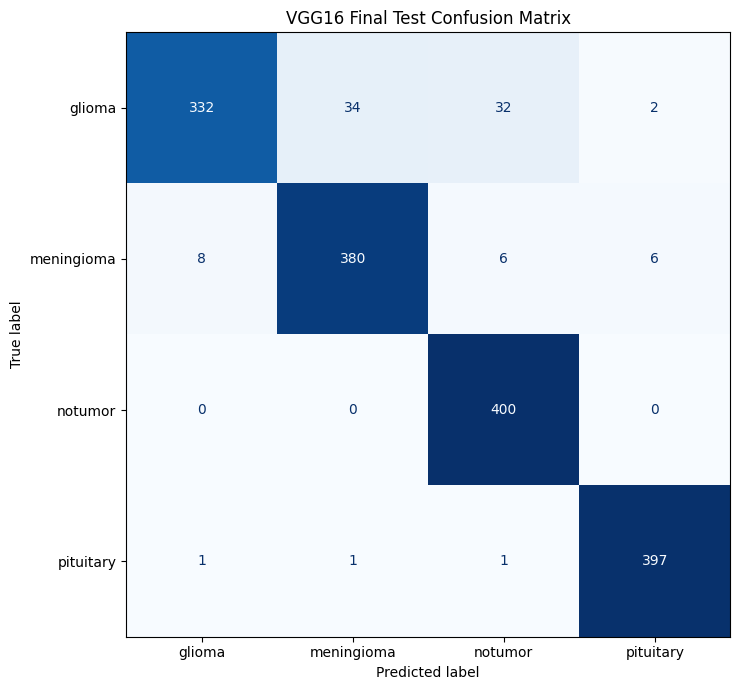

Saved: /content/brain-tumour-mri-classification/results/figures/vgg16_confusion_matrix.png


In [31]:
cm = confusion_matrix(test_true, test_pred)

fig, ax = plt.subplots(figsize=(8, 7))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

ax.set_title("VGG16 Final Test Confusion Matrix")
plt.tight_layout()

confusion_path = FIGURES_DIR / "vgg16_confusion_matrix.png"
plt.savefig(confusion_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", confusion_path)


## 23. Per-Class Results

Create a table with precision, recall, F1-score, and support for each class.


In [32]:
per_class = precision_recall_fscore_support(
    test_true,
    test_pred,
    labels=range(NUM_CLASSES),
    zero_division=0
)

per_class_df = pd.DataFrame(
    {
        "Class": CLASS_NAMES,
        "Precision": per_class[0],
        "Recall": per_class[1],
        "F1-score": per_class[2],
        "Support": per_class[3].astype(int)
    }
)

per_class_df


,Class,Precision,Recall,F1-score,Support
0,glioma,0.973607,0.8300,0.896086,400
1,meningioma,0.915663,0.9500,0.932515,400
2,notumor,0.911162,1.0000,0.953516,400
3,pituitary,0.980247,0.9925,0.986335,400


## 24. Save the Model and Results

Save the final VGG16 model, overall metrics, and per-class results for the final model comparison.


In [33]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": CLASS_NAMES,
        "architecture": "VGG16",
        "pretrained_weights": "ImageNet1K V1",
        "best_epoch": best_checkpoint["epoch"],
        "best_val_accuracy": best_checkpoint["val_accuracy"],
        "test_accuracy": test_accuracy,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1": test_f1,
        "test_roc_auc": test_roc_auc
    },
    FINAL_MODEL_PATH
)

metrics_path = METRICS_DIR / "vgg16_metrics.txt"

with open(metrics_path, "w", encoding="utf-8") as file:
    file.write("VGG16 - Brain Tumour MRI Classification\n")
    file.write("=" * 50 + "\n")
    file.write(f"Seed: {SEED}\n")
    file.write(f"Batch size: {BATCH_SIZE}\n")
    file.write(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}\n")
    file.write(f"Phase 1 epochs: {PHASE1_EPOCHS}\n")
    file.write(f"Fine-tuning epochs: {FINETUNE_EPOCHS}\n")
    file.write(f"Phase 1 learning rate: {PHASE1_LR}\n")
    file.write(f"Fine-tuning learning rate: {FINETUNE_LR}\n")
    file.write(f"Best fine-tuning epoch: {best_checkpoint['epoch']}\n")
    file.write(f"Best validation accuracy: {best_checkpoint['val_accuracy']:.4f}\n")
    file.write(f"Test accuracy: {test_accuracy:.4f}\n")
    file.write(f"Weighted precision: {test_precision:.4f}\n")
    file.write(f"Weighted recall: {test_recall:.4f}\n")
    file.write(f"Weighted F1-score: {test_f1:.4f}\n")
    file.write(f"Weighted ROC-AUC (OvR): {test_roc_auc:.4f}\n")
    file.write(f"Average inference time per image (ms): {avg_inference_ms:.3f}\n")
    file.write("\nClassification Report\n")
    file.write("-" * 50 + "\n")
    file.write(test_report)

per_class_path = METRICS_DIR / "vgg16_per_class_metrics.csv"
per_class_df.to_csv(per_class_path, index=False)

print("Final model saved:", FINAL_MODEL_PATH)
print("Metrics saved:", metrics_path)
print("Per-class metrics saved:", per_class_path)


Final model saved: /content/brain-tumour-mri-classification/results/checkpoints/vgg16_final.pth
Metrics saved: /content/brain-tumour-mri-classification/results/metrics/vgg16_metrics.txt
Per-class metrics saved: /content/brain-tumour-mri-classification/results/metrics/vgg16_per_class_metrics.csv


## 25. Final VGG16 Summary

Show the main VGG16 results in one table so they can be compared with the other models.


In [34]:
summary_df = pd.DataFrame(
    [{
        "Model": "VGG16",
        "Pretraining": "ImageNet",
        "Best Val Accuracy": best_checkpoint["val_accuracy"],
        "Test Accuracy": test_accuracy,
        "Precision": test_precision,
        "Recall": test_recall,
        "F1-score": test_f1,
        "ROC-AUC": test_roc_auc,
        "Inference ms/image": avg_inference_ms,
        "Total Parameters": total_params,
        "Fine-tune Trainable Parameters": finetune_trainable_params
    }]
)

summary_df


,Model,Pretraining,Best Val Accuracy,Test Accuracy,Precision,Recall,F1-score,ROC-AUC,Inference ms/image,Total Parameters,Fine-tune Trainable Parameters
0,VGG16,ImageNet,0.975,0.943125,0.94517,0.943125,0.942113,0.98988,5.240458,134276932,126641668


## 26. Completion Check

The VGG16 part is complete after training, fine-tuning, final testing, and saving all required results.


In [36]:
from pathlib import Path
import shutil

PROJECT_ROOT = Path("/content/brain-tumour-mri-classification")
RESULTS_DIR = PROJECT_ROOT / "results"

zip_base = Path("/content/vgg16_results")

zip_path = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=PROJECT_ROOT,
    base_dir="results"
)

print("ZIP created:", zip_path)
print("ZIP exists:", Path(zip_path).exists())
print(f"ZIP size: {Path(zip_path).stat().st_size / (1024**2):.2f} MB")

ZIP created: /content/vgg16_results.zip
ZIP exists: True
ZIP size: 2080.91 MB


In [37]:
from pathlib import Path

results_dir = Path("/content/brain-tumour-mri-classification/results")

for file in results_dir.rglob("*"):
    if file.is_file():
        size_mb = file.stat().st_size / (1024 ** 2)
        print(f"{size_mb:10.2f} MB  {file.relative_to(results_dir)}")

    512.24 MB  checkpoints/vgg16_final.pth
   1424.43 MB  checkpoints/vgg16_phase1_best.pth
   1478.45 MB  checkpoints/vgg16_finetuned_best.pth
      0.00 MB  metrics/vgg16_per_class_metrics.csv
      0.00 MB  metrics/vgg16_metrics.txt
      0.13 MB  figures/vgg16_finetuned_learning_curves.png
      0.10 MB  figures/vgg16_phase1_learning_curves.png
      0.04 MB  figures/vgg16_confusion_matrix.png


In [38]:
from pathlib import Path
import shutil

project = Path("/content/brain-tumour-mri-classification")
package = Path("/content/vgg16_final_results")

if package.exists():
    shutil.rmtree(package)

(package / "checkpoints").mkdir(parents=True)
(package / "metrics").mkdir()
(package / "figures").mkdir()

# Final trained model
shutil.copy2(
    project / "results/checkpoints/vgg16_final.pth",
    package / "checkpoints/vgg16_final.pth"
)

# Metrics
for file in (project / "results/metrics").iterdir():
    if file.is_file():
        shutil.copy2(file, package / "metrics" / file.name)

# Figures
for file in (project / "results/figures").iterdir():
    if file.is_file():
        shutil.copy2(file, package / "figures" / file.name)

zip_path = shutil.make_archive(
    "/content/vgg16_final_results",
    "zip",
    root_dir="/content",
    base_dir="vgg16_final_results"
)

print("ZIP created:", zip_path)
print(f"ZIP size: {Path(zip_path).stat().st_size / (1024**2):.2f} MB")

ZIP created: /content/vgg16_final_results.zip
ZIP size: 475.82 MB


In [39]:
from google.colab import files

files.download("/content/vgg16_final_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>